[match_pairs:tufts] 1000 images, 1000 masks, 1000 matched, 0 unmatched.
[match_pairs:children_train] 70 images, 70 masks, 0 matched, 70 unmatched.
[match_pairs:children_test] 30 images, 30 masks, 0 matched, 30 unmatched.
[match_pairs:children_supplemental] 93 images, 93 masks, 0 matched, 93 unmatched.

Total images: 1000
Per-source counts:
source
tufts    1000
Name: count, dtype: int64

Images with at least one annotated lesion: 339 (33.9%)
Mean foreground pixel ratio: 0.00325
Median foreground pixel ratio: 0.00000
Background:foreground pixel ratio ≈ 306.7:1

Aspect ratio — mean: 1.92, min: 1.92, max: 1.92
Image size — mean HxW: 840 x 1615

Lesion count distribution:
num_lesions
0     661
1     120
2      95
3      58
4      32
5      16
6       6
7       4
8       4
9       1
10      2
11      1
Name: count, dtype: int64


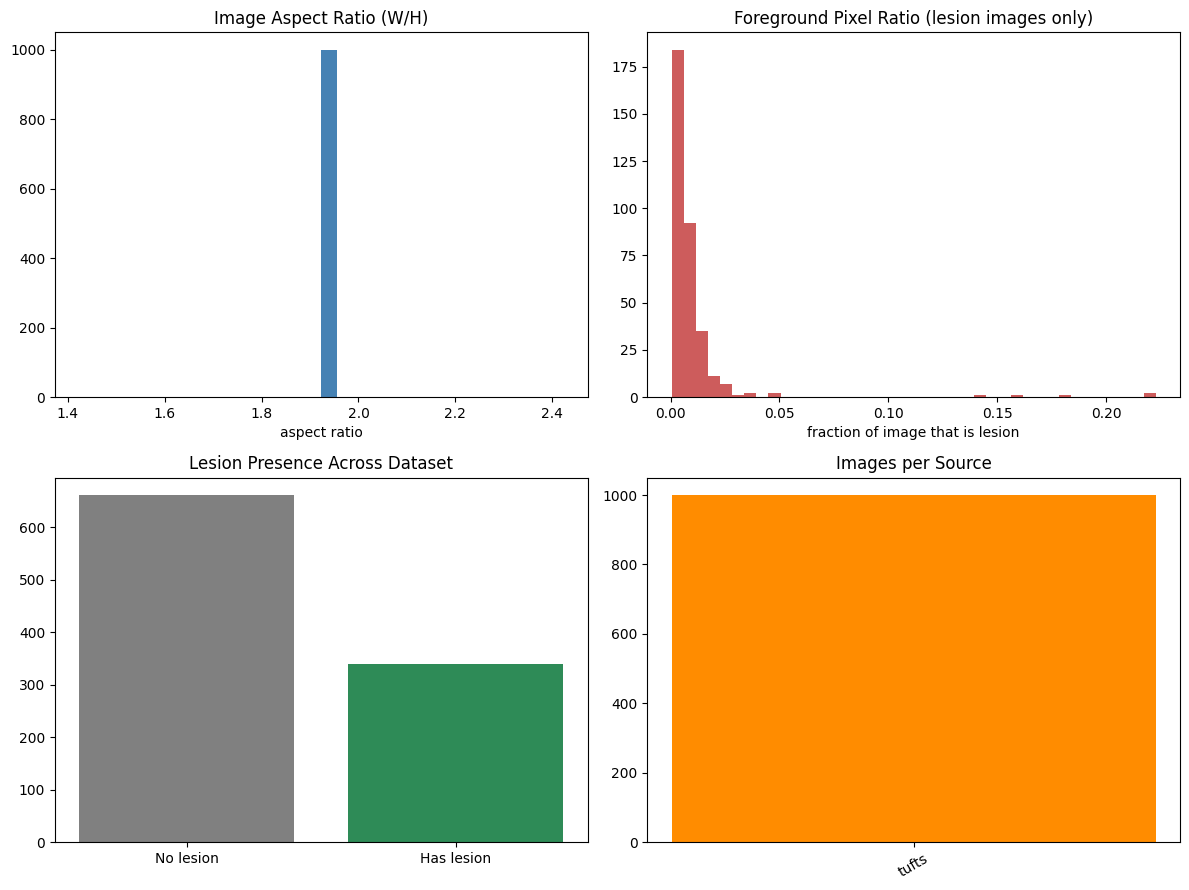

Saved plots to eda_plots.png


In [2]:
"""
EDA for the OPG cavity/lesion segmentation dataset.
Analyzes class imbalance (foreground vs background pixels) and image aspect ratios
across all combined image/mask sources.
"""

import os
import glob

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TUFTS_ROOT = "/kaggle/input/datasets/tommyngx/the-tufts-dental-database-2022"
CHILDREN_CARIES_ROOT = (
    "/kaggle/input/datasets/truthisneverlinear/childrens-dental-panoramic-radiographs-dataset"
    "/Dental_dataset/Childrens dental caries segmentation dataset"
)

# name, image_dir, mask_dir — same sources as train.py
DATASET_SOURCES = [
    ("tufts", f"{TUFTS_ROOT}/Radiographs/Radiographs", f"{TUFTS_ROOT}/Expert/Expert/mask"),
    ("children_train", f"{CHILDREN_CARIES_ROOT}/Train/images", f"{CHILDREN_CARIES_ROOT}/Train/mask"),
    ("children_test", f"{CHILDREN_CARIES_ROOT}/Test/images", f"{CHILDREN_CARIES_ROOT}/Test/mask"),
    ("children_supplemental", f"{CHILDREN_CARIES_ROOT}/Supplemental content93/images",
     f"{CHILDREN_CARIES_ROOT}/Supplemental content93/mask"),
]

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def _stem(path):
    """Filename stem, lowercased, for extension- and case-insensitive matching."""
    return os.path.splitext(os.path.basename(path))[0].strip().lower()


def _glob_recursive(root_dir, extensions):
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext}"), recursive=True))
        files.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext.upper()}"), recursive=True))
    return sorted(set(files))


def _debug_list_parent(missing_dir):
    """When a configured directory is empty/missing, print what's actually on
    disk one level up, so a folder-name mismatch (e.g. 'mask' vs 'masks',
    'images' vs 'Images') is visible immediately instead of requiring a
    separate debugging pass."""
    parent = os.path.dirname(os.path.normpath(missing_dir))
    try:
        if os.path.isdir(parent):
            entries = os.listdir(parent)
            print(f"    -> contents of {parent}: {entries[:20]}"
                  f"{' ...' if len(entries) > 20 else ''}")
        else:
            print(f"    -> parent directory also does not exist: {parent}")
    except OSError as e:
        print(f"    -> could not list {parent}: {e}")


def match_pairs(img_dir, mask_dir, extensions=IMG_EXTENSIONS, source_name=""):
    """Match images to masks by filename stem.

    Recursive (handles nested subfolders), case-insensitive, and tolerant of
    mismatched extensions between an image and its mask (e.g. img.jpg / img.png).
    Prints diagnostics instead of failing silently, since a silent 0-pair
    source is exactly what shrank the effective dataset from ~1000 to 237
    images previously.
    """
    if not os.path.isdir(img_dir):
        print(f"[match_pairs:{source_name}] WARNING: image dir does not exist: {img_dir}")
        _debug_list_parent(img_dir)
        return []
    if not os.path.isdir(mask_dir):
        print(f"[match_pairs:{source_name}] WARNING: mask dir does not exist: {mask_dir}")
        _debug_list_parent(mask_dir)
        return []

    mask_files = _glob_recursive(mask_dir, extensions)
    img_files = _glob_recursive(img_dir, extensions)

    mask_lookup = {}
    collisions = 0
    for p in mask_files:
        key = _stem(p)
        if key in mask_lookup:
            collisions += 1
        else:
            mask_lookup[key] = p
    if collisions:
        print(f"[match_pairs:{source_name}] {collisions} duplicate mask stems "
              f"found (kept first occurrence).")

    pairs, unmatched = [], 0
    for img_path in img_files:
        mask_path = mask_lookup.get(_stem(img_path))
        if mask_path is not None:
            pairs.append((img_path, mask_path))
        else:
            unmatched += 1

    print(f"[match_pairs:{source_name}] {len(img_files)} images, {len(mask_files)} masks, "
          f"{len(pairs)} matched, {unmatched} unmatched.")

    if len(img_files) == 0:
        _debug_list_parent(img_dir)

    return pairs



def collect_stats():
    rows = []

    for source_name, img_dir, mask_dir in DATASET_SOURCES:
        pairs = match_pairs(img_dir, mask_dir, source_name=source_name)

        for img_path, mask_path in pairs:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if img is None or mask is None:
                continue

            h, w = img.shape
            mask_bin = (mask > 0).astype(np.uint8)
            fg_pixels = int(mask_bin.sum())
            total_pixels = mask_bin.size

            n_labels, _ = cv2.connectedComponents(mask_bin)

            rows.append({
                "source": source_name,
                "filename": os.path.basename(img_path),
                "height": h,
                "width": w,
                "aspect_ratio": round(w / h, 3),
                "fg_pixels": fg_pixels,
                "fg_ratio": fg_pixels / total_pixels,
                "num_lesions": max(n_labels - 1, 0),
                "has_lesion": fg_pixels > 0,
            })

    return pd.DataFrame(rows)


def summarize(df):
    print(f"\nTotal images: {len(df)}")
    print("Per-source counts:")
    print(df["source"].value_counts())
    print()
    print(f"Images with at least one annotated lesion: {df['has_lesion'].sum()} "
          f"({df['has_lesion'].mean() * 100:.1f}%)")
    print(f"Mean foreground pixel ratio: {df['fg_ratio'].mean():.5f}")
    print(f"Median foreground pixel ratio: {df['fg_ratio'].median():.5f}")
    print(f"Background:foreground pixel ratio ≈ {(1 - df['fg_ratio'].mean()) / df['fg_ratio'].mean():.1f}:1")
    print()
    print(f"Aspect ratio — mean: {df['aspect_ratio'].mean():.2f}, "
          f"min: {df['aspect_ratio'].min():.2f}, max: {df['aspect_ratio'].max():.2f}")
    print(f"Image size — mean HxW: {df['height'].mean():.0f} x {df['width'].mean():.0f}")
    print()
    print("Lesion count distribution:")
    print(df['num_lesions'].value_counts().sort_index())


def plot_distributions(df, out_path="eda_plots.png"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].hist(df["aspect_ratio"], bins=30, color="steelblue")
    axes[0, 0].set_title("Image Aspect Ratio (W/H)")
    axes[0, 0].set_xlabel("aspect ratio")

    axes[0, 1].hist(df[df["fg_ratio"] > 0]["fg_ratio"], bins=40, color="indianred")
    axes[0, 1].set_title("Foreground Pixel Ratio (lesion images only)")
    axes[0, 1].set_xlabel("fraction of image that is lesion")

    axes[1, 0].bar(["No lesion", "Has lesion"],
                    [(~df["has_lesion"]).sum(), df["has_lesion"].sum()],
                    color=["gray", "seagreen"])
    axes[1, 0].set_title("Lesion Presence Across Dataset")

    source_counts = df["source"].value_counts()
    axes[1, 1].bar(source_counts.index, source_counts.values, color="darkorange")
    axes[1, 1].set_title("Images per Source")
    axes[1, 1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved plots to {out_path}")


if __name__ == "__main__":
    df = collect_stats()
    df.to_csv("eda_stats.csv", index=False)
    summarize(df)
    plot_distributions(df)

In [7]:
import os
import re
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

CONFIG = {
    "seed": 42,
    "batch_size": 16,
    "epochs": 60,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "img_size": (512, 512),
    "min_blob_size": 6,       
    "morph_kernel": 3,
    "use_morphology": True,
    "threshold_sweep": np.linspace(0.10, 0.85, 16),  
    "patience": 12,
    
    "pos_weight_cap": 25.0,       
    "pos_sample_multiplier": 3.0, 
    "tversky_alpha": 0.35,        
    "tversky_beta": 0.65,         
    "focal_gamma": 0.75,
    "bce_weight": 0.5,            
}

SEED = CONFIG["seed"]
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

TUFTS_ROOT = "/kaggle/input/datasets/tommyngx/the-tufts-dental-database-2022"
CHILDREN_CARIES_ROOT = (
    "/kaggle/input/datasets/truthisneverlinear/childrens-dental-panoramic-radiographs-dataset"
    "/Dental_dataset/Childrens dental caries segmentation dataset"
)

DATASET_SOURCES = [
    ("tufts",
     f"{TUFTS_ROOT}/Radiographs/Radiographs",
     f"{TUFTS_ROOT}/Expert/Expert/mask"),
    ("children_train",
     f"{CHILDREN_CARIES_ROOT}/Train/images",
     f"{CHILDREN_CARIES_ROOT}/Train/mask"),
    ("children_test",
     f"{CHILDREN_CARIES_ROOT}/Test/images",
     f"{CHILDREN_CARIES_ROOT}/Test/mask"),
    ("children_supp",
     f"{CHILDREN_CARIES_ROOT}/Supplemental content93/images",
     f"{CHILDREN_CARIES_ROOT}/Supplemental content93/mask"),
]

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

_PREFIX_RE = re.compile(r"^(mask|img|image|caries|label|gt|annotation|pseudo)[_\-\s]*", re.I)
_SUFFIX_RE = re.compile(r"[_\-\s]*(mask|label|seg|segmentation|annotation|gt|pseudo)$", re.I)

def _stem(path: str) -> str:
    """Normalize so cate1_000.png and cate1_000_pseudo.png both become cate1000.
    Loops the prefix/suffix strip in case of stacked tags, then collapses
    everything else to bare alphanumerics so spacing/dash/zero-padding
    differences can't cause a miss."""
    name = os.path.splitext(os.path.basename(path))[0].strip().lower()
    prev = None
    while prev != name:
        prev = name
        name = _PREFIX_RE.sub("", name)
        name = _SUFFIX_RE.sub("", name)
    name = re.sub(r"[^a-z0-9]", "", name)
    return name

def _glob_recursive(root_dir, extensions):
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext}"), recursive=True))
        files.extend(glob.glob(os.path.join(root_dir, "**", f"*{ext.upper()}"), recursive=True))
    return sorted(set(files))

def _debug_list_parent(missing_dir):
    parent = os.path.dirname(os.path.normpath(missing_dir))
    try:
        if os.path.isdir(parent):
            entries = os.listdir(parent)
            print(f"    -> contents of {parent}: {entries[:15]}{' ...' if len(entries) > 15 else ''}")
        else:
            print(f"    -> parent also missing: {parent}")
    except OSError as e:
        print(f"    -> could not list {parent}: {e}")

def match_pairs(img_dir, mask_dir, source_name="source", debug_samples=6):
    if not os.path.isdir(img_dir):
        print(f"[{source_name}] WARNING: image dir missing -> {img_dir}")
        _debug_list_parent(img_dir)
        return []
    if not os.path.isdir(mask_dir):
        print(f"[{source_name}] WARNING: mask dir missing -> {mask_dir}")
        _debug_list_parent(mask_dir)
        return []

    img_files  = _glob_recursive(img_dir,  IMG_EXTENSIONS)
    mask_files = _glob_recursive(mask_dir, IMG_EXTENSIONS)

    mask_dict = {}
    collisions = 0
    for f in mask_files:
        key = _stem(f)
        if key in mask_dict:
            collisions += 1
        else:
            mask_dict[key] = f
    if collisions:
        print(f"[{source_name}] {collisions} duplicate mask stems (kept first)")

    pairs = []
    unmatched = 0
    for f in img_files:
        key = _stem(f)
        if key in mask_dict:
            pairs.append((f, mask_dict[key]))
        else:
            unmatched += 1

    print(f"[{source_name}] {len(img_files):4d} imgs | {len(mask_files):4d} masks -> "
          f"{len(pairs):4d} matched | {unmatched:3d} unmatched")

    if img_files and len(pairs) < 0.6 * len(img_files):
        print(f"[{source_name}] low match rate - sample stems:")
        for f in img_files[:debug_samples]:
            print(f"    img  {os.path.basename(f):40s} -> {_stem(f)}")
        for f in mask_files[:debug_samples]:
            print(f"    mask {os.path.basename(f):40s} -> {_stem(f)}")

    return pairs

def build_file_lists(val_size=0.15, test_size=0.15):
    all_pairs   = []
    all_sources = []

    for source_name, img_dir, mask_dir in DATASET_SOURCES:
        pairs = match_pairs(img_dir, mask_dir, source_name=source_name)
        for img_p, mask_p in pairs:
            all_pairs.append((img_p, mask_p))
            all_sources.append(source_name)

    print(f"\n--> Total pairs retained (healthy + positive): {len(all_pairs)}")

    if len(all_pairs) == 0:
        raise RuntimeError("Zero pairs found. Check path / matching diagnostics above.")

    imgs  = [p[0] for p in all_pairs]
    masks = [p[1] for p in all_pairs]

    counts = Counter(all_sources)
    can_stratify = all(c >= 2 for c in counts.values()) and len(counts) > 1
    stratify_arg = all_sources if can_stratify else None
    if not can_stratify:
        print(f"[split] Stratification skipped - source counts: {dict(counts)}")

    if stratify_arg is not None:
        train_imgs, temp_imgs, train_masks, temp_masks, _, temp_sources = train_test_split(
            imgs, masks, all_sources,
            test_size=(val_size + test_size),
            random_state=SEED,
            stratify=stratify_arg,
        )
    else:
        train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
            imgs, masks, test_size=(val_size + test_size), random_state=SEED
        )
        temp_sources = None

    rel_test = test_size / (val_size + test_size)
    val_imgs, test_imgs, val_masks, test_masks = train_test_split(
        temp_imgs, temp_masks,
        test_size=rel_test,
        random_state=SEED,
        stratify=temp_sources,
    )

    return (train_imgs, train_masks), (val_imgs, val_masks), (test_imgs, test_masks)

class DentalDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.img_paths[idx], cv2.IMREAD_COLOR)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return img, mask

def get_train_transforms():
    return A.Compose([
        A.Resize(*CONFIG["img_size"], interpolation=cv2.INTER_NEAREST),
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.93, 1.07),
            translate_percent=(-0.04, 0.04),
            rotate=(-7, 7),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.35,
        ),
        A.RandomBrightnessContrast(brightness_limit=0.12, contrast_limit=0.12, p=0.3),
        A.GaussNoise(std_range=(0.01, 0.05), p=0.15),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(*CONFIG["img_size"]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class CombinedLoss(nn.Module):
    def __init__(self, pos_weight, alpha=0.35, beta=0.65, gamma=0.75, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.register_buffer("pos_weight", pos_weight)
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.bce_weight = bce_weight
        self.smooth = smooth

    def _focal_tversky(self, logits, targets):
        probs = torch.sigmoid(logits).reshape(logits.size(0), -1)
        targets = targets.reshape(targets.size(0), -1)
        tp = (probs * targets).sum(dim=1)
        fp = (probs * (1 - targets)).sum(dim=1)
        fn = ((1 - probs) * targets).sum(dim=1)
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        loss = (1.0 - tversky).clamp(min=1e-6).mean()
        return loss.pow(self.gamma)

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight)
        ft = self._focal_tversky(logits, targets)
        return self.bce_weight * bce + (1 - self.bce_weight) * ft


def compute_pos_weight(mask_paths, cap=25.0):
    """Background:foreground pixel ratio across the given masks, used as
    BCE's pos_weight. Capped (default 25x) because the raw ~300:1 ratio
    tends to push the model to over-predict everywhere — that trades away
    precision faster than it buys back recall."""
    total_fg, total_px = 0, 0
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        total_fg += int((m > 0).sum())
        total_px += m.size
    total_bg = total_px - total_fg
    ratio = total_bg / max(total_fg, 1)
    ratio = min(ratio, cap)
    print(f"[loss] fg:bg pixel ratio -> pos_weight = {ratio:.2f} (capped at {cap})")
    return torch.tensor(ratio, dtype=torch.float32)


def compute_sample_weights(mask_paths, pos_multiplier=3.0):
    """Per-image sampling weight for WeightedRandomSampler: images with at
    least one lesion pixel are oversampled relative to healthy images, so
    the rare positive class isn't diluted by an imbalanced batch mix before
    the loss function even sees it."""
    weights = []
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        has_lesion = m is not None and (m > 0).any()
        weights.append(pos_multiplier if has_lesion else 1.0)
    return torch.tensor(weights, dtype=torch.double)

def compute_global_metrics(total_tp, total_fp, total_fn, eps=1e-7):
    precision = total_tp / (total_tp + total_fp + eps)
    recall    = total_tp / (total_tp + total_fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = total_tp / (total_tp + total_fp + total_fn + eps)
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

def compute_metrics_tensor(preds, targets, eps=1e-7):
    """Pooled precision/recall/F1/IoU directly from prediction/target tensors.
    NOTE: this was called but never defined in the previous version of this
    file (compute_metrics_tensor was referenced at two call sites with no
    matching `def` anywhere) — that's a guaranteed NameError the moment
    validation runs unless it happened to be defined in a separate notebook
    cell you didn't paste. Defining it here removes that crash risk."""
    preds   = preds.float()
    targets = targets.float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    return compute_global_metrics(tp, fp, fn, eps=eps)
                                  
@torch.no_grad()
def evaluate_fast(model, loader, criterion, thresholds=None):
    if thresholds is None:
        thresholds = CONFIG["threshold_sweep"]

    model.eval()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        all_probs.append(torch.sigmoid(logits).cpu())
        all_targets.append(masks.cpu())

    all_probs   = torch.cat(all_probs,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    best_t, best_metrics = 0.35, None
    for t in thresholds:
        preds = (all_probs > t).float()
        metrics = compute_metrics_tensor(preds, all_targets)
        if best_metrics is None or metrics["f1"] > best_metrics["f1"]:
            best_metrics, best_t = metrics, float(t)

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, best_metrics, best_t

def postprocess_mask(prob_map, threshold=0.5, min_blob_size=30,
                      morph_kernel=3, use_morphology=True):
    binary = (prob_map > threshold).astype(np.uint8)
    if use_morphology and morph_kernel > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    if min_blob_size > 0:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] < min_blob_size:
                binary[labels == i] = 0
    return binary.astype(np.float32)

@torch.no_grad()
def evaluate_test_with_postprocess(model, loader, criterion, threshold):
    model.eval()
    running_loss = 0.0
    total_tp = total_fp = total_fn = 0.0

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, masks)
        running_loss += loss.item() * imgs.size(0)

        probs = torch.sigmoid(logits).cpu().numpy()
        targets = masks.cpu().numpy()

        for i in range(probs.shape[0]):
            clean = postprocess_mask(
                probs[i, 0],
                threshold=threshold,
                min_blob_size=CONFIG["min_blob_size"],
                morph_kernel=CONFIG["morph_kernel"],
                use_morphology=CONFIG["use_morphology"],
            )
            target_i = targets[i, 0]
            total_tp += float((clean * target_i).sum())
            total_fp += float((clean * (1 - target_i)).sum())
            total_fn += float(((1 - clean) * target_i).sum())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_global_metrics(total_tp, total_fp, total_fn)
    return avg_loss, metrics

def main():
    (train_img, train_mask), (val_img, val_mask), (test_img, test_mask) = build_file_lists()
    print(f"\nFinal split -> Train: {len(train_img)} | Val: {len(val_img)} | Test: {len(test_img)}\n")

    train_ds = DentalDataset(train_img, train_mask, get_train_transforms())
    val_ds   = DentalDataset(val_img,   val_mask,   get_val_transforms())
    test_ds  = DentalDataset(test_img,  test_mask,  get_val_transforms())
    sample_weights = compute_sample_weights(train_mask, pos_multiplier=CONFIG["pos_sample_multiplier"])
    train_sampler = torch.utils.data.WeightedRandomSampler(
        sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=train_sampler,
                               num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False,
                               num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False,
                               num_workers=2, pin_memory=True)

    model = smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(DEVICE)

    pos_weight = compute_pos_weight(train_mask, cap=CONFIG["pos_weight_cap"])
    criterion = CombinedLoss(
        pos_weight=pos_weight,
        alpha=CONFIG["tversky_alpha"],
        beta=CONFIG["tversky_beta"],
        gamma=CONFIG["focal_gamma"],
        bce_weight=CONFIG["bce_weight"],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                                   weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"], eta_min=1e-6
    )

    best_val_f1 = 0.0
    best_threshold = 0.35
    patience_counter = 0

    print("Starting training...\n")
    for epoch in range(1, CONFIG["epochs"] + 1):
        model.train()
        train_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(imgs)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_loader.dataset)

        val_loss, val_metrics, val_t = evaluate_fast(model, val_loader, criterion)
        scheduler.step()

        print(
            f"Epoch {epoch:03d} | lr {scheduler.get_last_lr()[0]:.2e} | "
            f"train {train_loss:.4f} | val {val_loss:.4f} | "
            f"F1 {val_metrics['f1']:.4f} | Rec {val_metrics['recall']:.4f} | "
            f"IoU {val_metrics['iou']:.4f} | thr {val_t:.2f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_threshold = val_t
            torch.save(model.state_dict(), "best_model.pth")
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    print(f"\nTraining finished. Best Val F1 = {best_val_f1:.4f} @ threshold {best_threshold:.2f}")

    model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
    _, test_metrics = evaluate_test_with_postprocess(
        model, test_loader, criterion, threshold=best_threshold
    )

    print(f"Precision : {test_metrics['precision']:.4f}")
    print(f"Recall    : {test_metrics['recall']:.4f}")
    print(f"F1        : {test_metrics['f1']:.4f}")
    print(f"IoU       : {test_metrics['iou']:.4f}")

    return model, train_loader, val_loader, test_loader, best_threshold, best_val_f1

if __name__ == "__main__":
    model, train_loader, val_loader, test_loader, best_threshold, best_val_f1 = main()

Using device: cuda
[tufts] 1000 imgs | 1000 masks -> 1000 matched |   0 unmatched
[children_train]   70 imgs |   70 masks ->   70 matched |   0 unmatched
[children_test]   30 imgs |   30 masks ->   30 matched |   0 unmatched
[children_supp]   93 imgs |   93 masks ->   93 matched |   0 unmatched

--> Total pairs retained (healthy + positive): 1193

Final split -> Train: 835 | Val: 179 | Test: 179

[loss] fg:bg pixel ratio -> pos_weight = 25.00 (capped at 25.0)
Starting training...

Epoch 001 | lr 3.00e-04 | train 0.8868 | val 0.8167 | F1 0.3815 | Rec 0.8693 | IoU 0.2357 | thr 0.85
Epoch 002 | lr 2.99e-04 | train 0.6949 | val 0.7388 | F1 0.4100 | Rec 0.9210 | IoU 0.2579 | thr 0.85
Epoch 003 | lr 2.98e-04 | train 0.6232 | val 0.6145 | F1 0.7313 | Rec 0.8543 | IoU 0.5764 | thr 0.85
Epoch 004 | lr 2.97e-04 | train 0.5611 | val 0.5997 | F1 0.7518 | Rec 0.8355 | IoU 0.6024 | thr 0.85
Epoch 005 | lr 2.95e-04 | train 0.5313 | val 0.5955 | F1 0.8042 | Rec 0.8492 | IoU 0.6725 | thr 0.85
Epoch 006

Using existing DataLoader: `test_loader`


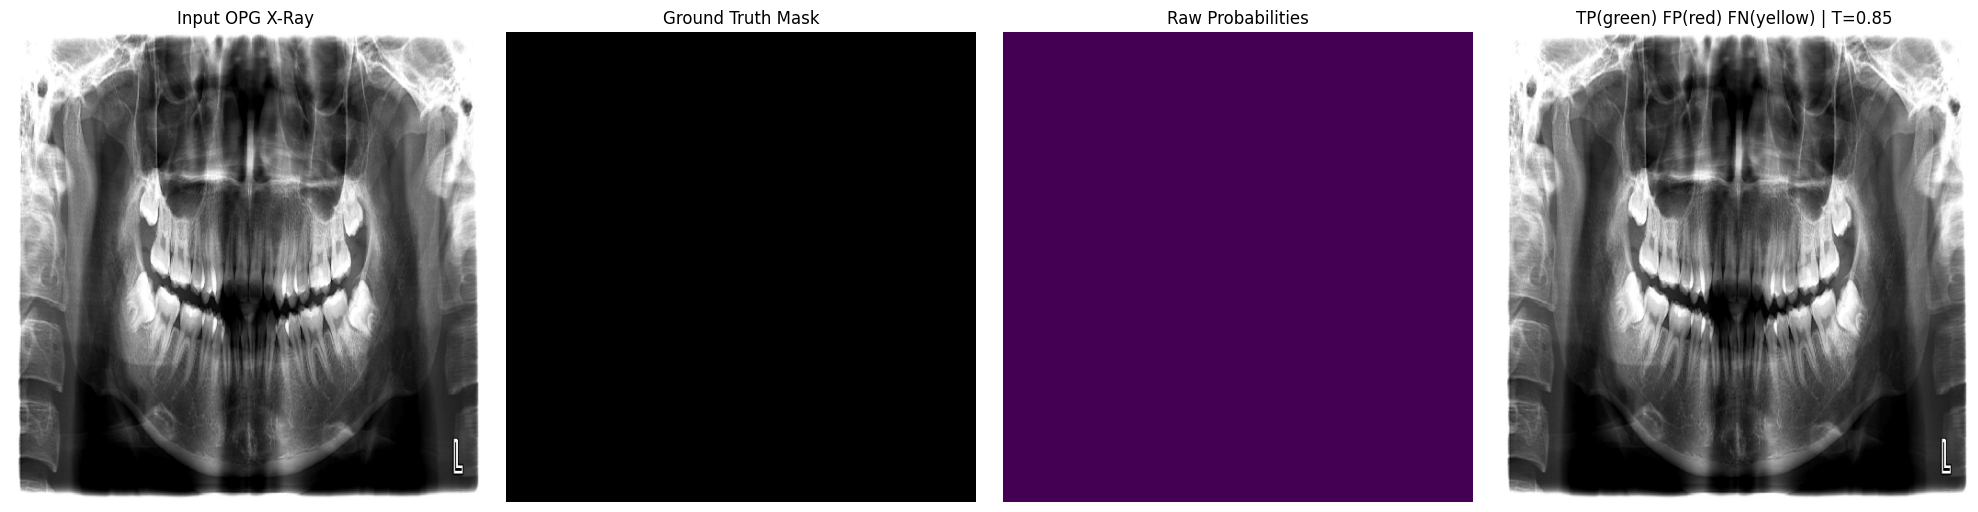

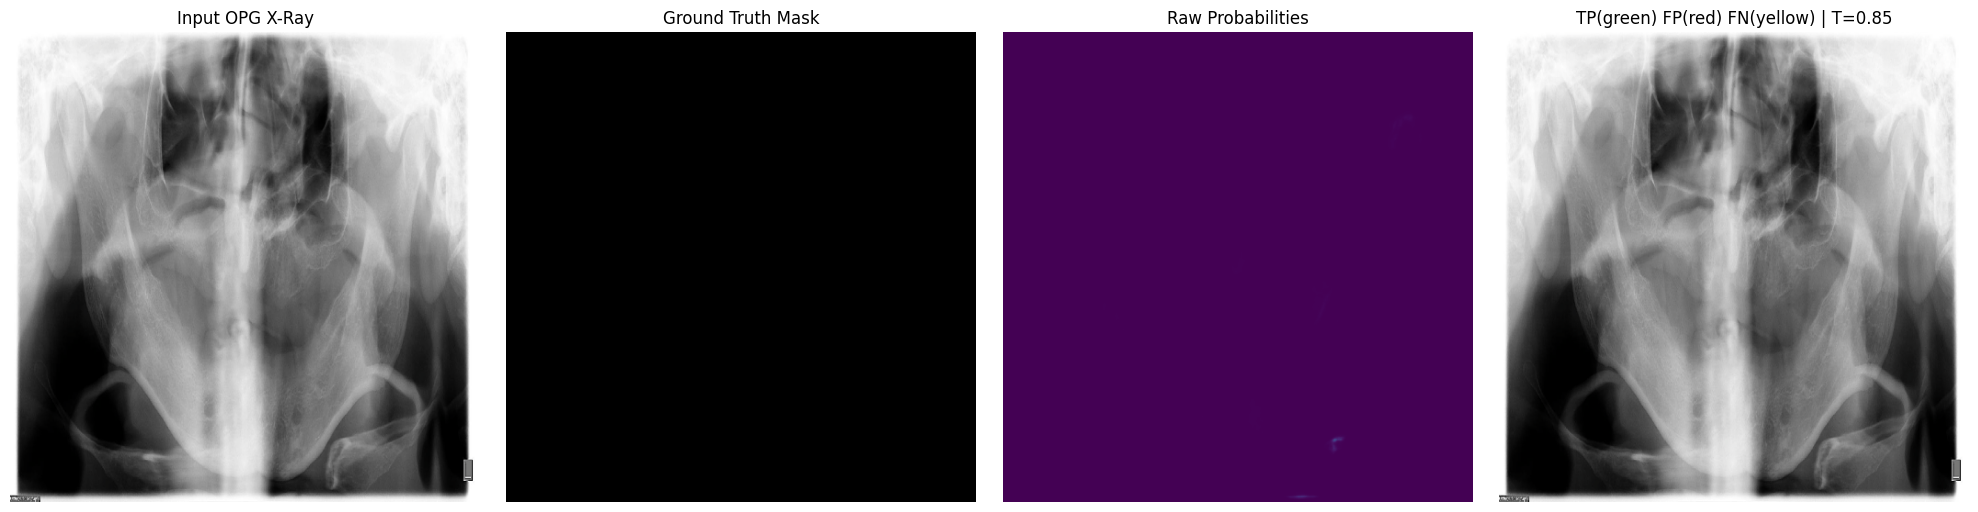

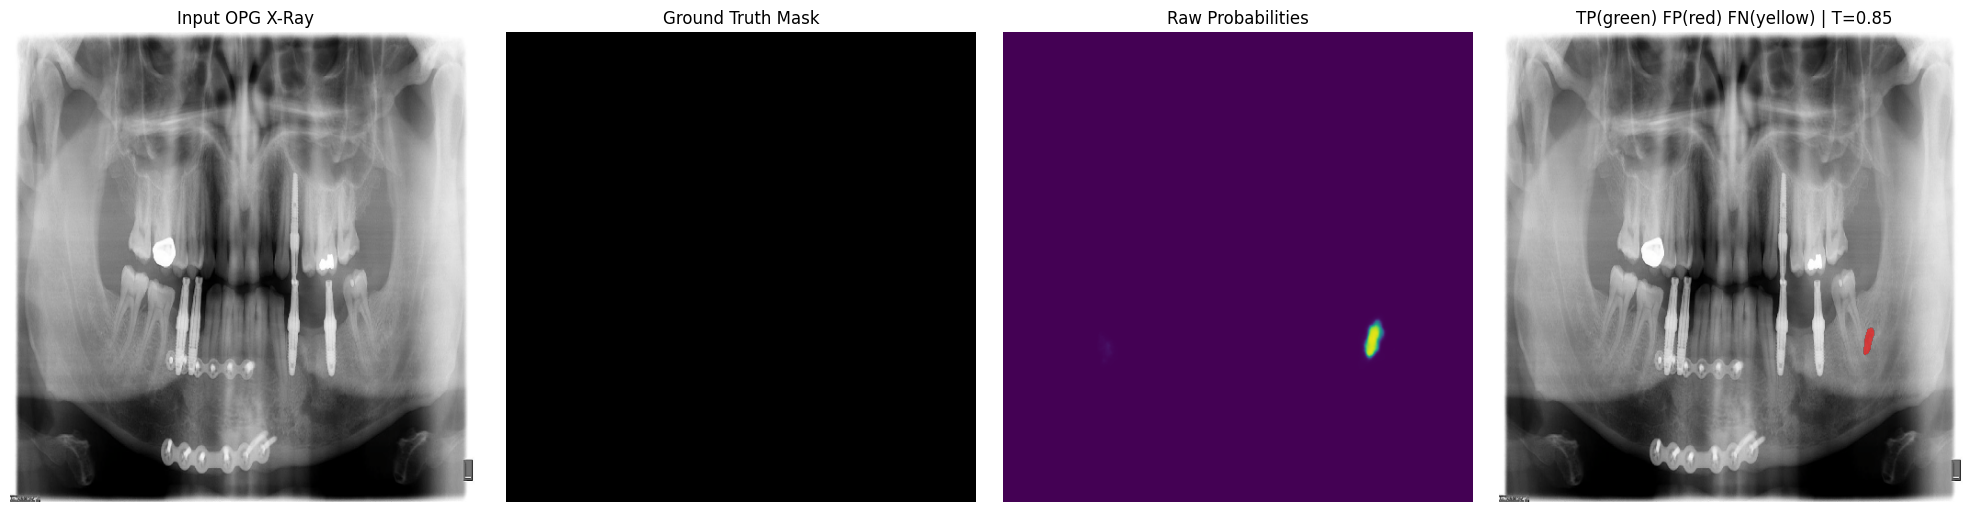

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def make_overlay(pred_bin, gt_bin):
    h, w = pred_bin.shape
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    tp = (pred_bin == 1) & (gt_bin == 1)
    fp = (pred_bin == 1) & (gt_bin == 0)
    fn = (pred_bin == 0) & (gt_bin == 1)

    overlay[tp] = (0.0, 1.0, 0.0, 0.6)  # TP: Green
    overlay[fp] = (1.0, 0.0, 0.0, 0.6)  # FP: Red
    overlay[fn] = (1.0, 1.0, 0.0, 0.6)  # FN: Yellow
    return overlay


def visualize_test_predictions(model, loader, threshold=0.30, num_samples=3):
    model.eval()
    samples_shown = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(DEVICE)
            probs = torch.sigmoid(model(imgs)).cpu().numpy()
            for i in range(imgs.size(0)):
                if samples_shown >= num_samples:
                    return
                img_np = imgs[i].permute(1, 2, 0).cpu().numpy()
                img_np = (img_np * STD + MEAN).clip(0, 1)
                true_mask = masks[i, 0].cpu().numpy().astype(np.uint8)

                if "postprocess_mask" in globals():
                    pred_mask = postprocess_mask(probs[i, 0], threshold=threshold)
                else:
                    pred_mask = (probs[i, 0] > threshold).astype(np.uint8)

                overlay = make_overlay(pred_mask, true_mask)
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                axes[0].imshow(img_np)
                axes[0].set_title("Input OPG X-Ray")
                axes[1].imshow(true_mask, cmap="gray")
                axes[1].set_title("Ground Truth Mask")
                axes[2].imshow(probs[i, 0], cmap="viridis", vmin=0, vmax=1)
                axes[2].set_title("Raw Probabilities")
                axes[3].imshow(img_np)
                axes[3].imshow(overlay)
                axes[3].set_title(f"TP(green) FP(red) FN(yellow) | T={threshold:.2f}")
                for ax in axes:
                    ax.axis("off")
                plt.tight_layout()
                plt.savefig(f"prediction_sample_{samples_shown + 1}.png", dpi=150, bbox_inches="tight")
                plt.show()
                samples_shown += 1


loader_to_use = None
for candidate in ["test_loader", "val_loader", "test_dl", "val_dl", "loader"]:
    if candidate in globals():
        loader_to_use = globals()[candidate]
        print(f"Using existing DataLoader: `{candidate}`")
        break
if loader_to_use is None:
    raise NameError(
        "No active DataLoader found in memory! Run train.py's main() first "
        "(e.g. `model, train_loader, val_loader, test_loader, best_threshold, "
        "best_val_f1 = main()`) so test_loader exists in this session."
    )

if "model" not in globals():
    raise NameError(
        "Variable `model` not found. Run train.py's main() first so `model` "
        "exists in this session — see the NameError above for the exact call."
    )

threshold_to_use = globals().get("best_t", globals().get("best_threshold", 0.35))
if "best_t" not in globals() and "best_threshold" not in globals():
    print("WARNING: no trained threshold found in this session — using fallback 0.35. "
          "Run train.py's main() and capture its return values first for the real one.")

visualize_test_predictions(
    model=model,
    loader=loader_to_use,
    threshold=threshold_to_use,
    num_samples=3,
)

In [ ]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    if len(files) > 0:
        print(f"Directory: {root} | Contains {len(files)} files")